In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = {
    "Student": ["A", "B", "C", "D", "E", "F", "G", "H"],
    "Maths": [78, 45, 89, 66, 92, 56, 74, 81],
    "Science": [88, 52, 94, 70, 85, 60, 73, 90],
    "English": [69, 75, 80, 55, 91, 62, 77, 84],
    "Gender": ["M", "F", "M", "F", "M", "F", "M", "F"]
}

df = pd.DataFrame(data)
print(df)

  Student  Maths  Science  English Gender
0       A     78       88       69      M
1       B     45       52       75      F
2       C     89       94       80      M
3       D     66       70       55      F
4       E     92       85       91      M
5       F     56       60       62      F
6       G     74       73       77      M
7       H     81       90       84      F


In [3]:
df

,Student,Maths,Science,English,Gender
0,A,78,88,69,M
1,B,45,52,75,F
2,C,89,94,80,M
3,D,66,70,55,F
4,E,92,85,91,M
5,F,56,60,62,F
6,G,74,73,77,M
7,H,81,90,84,F


In [8]:
describe=df["Maths"].describe()
describe

count     8.000000
mean     72.625000
std      16.159363
min      45.000000
25%      63.500000
50%      76.000000
75%      83.000000
max      92.000000
Name: Maths, dtype: float64

In [10]:
median=df["Maths"].median()
median

76.0

In [12]:
describe_S=df["Science"].describe()
describe_S

count     8.000000
mean     76.500000
std      15.212777
min      52.000000
25%      67.500000
50%      79.000000
75%      88.500000
max      94.000000
Name: Science, dtype: float64

In [13]:
median_S=df["Science"].median()
median_S

79.0

In [24]:
sort_M=np.sort(df["Maths"])[::-1]
print("Top_3-",sort_M[0:3])

Top_3- [92 89 81]


In [27]:
sort_S=np.sort(df["Science"])[::-1]
print("Top_3-",sort_S[0:3])

Top_3- [94 90 88]


In [28]:
df=df.assign(Total_Marks=df["Maths"]+df["Science"]+df["English"])
df

,Student,Maths,Science,English,Gender,Total_Marks
0,A,78,88,69,M,235
1,B,45,52,75,F,172
2,C,89,94,80,M,263
3,D,66,70,55,F,191
4,E,92,85,91,M,268
5,F,56,60,62,F,178
6,G,74,73,77,M,224
7,H,81,90,84,F,255


In [31]:
df.groupby("Gender")["Total_Marks"].mean()

Gender
F    199.0
M    247.5
Name: Total_Marks, dtype: float64

Text(0, 0.5, 'Total_Marks')

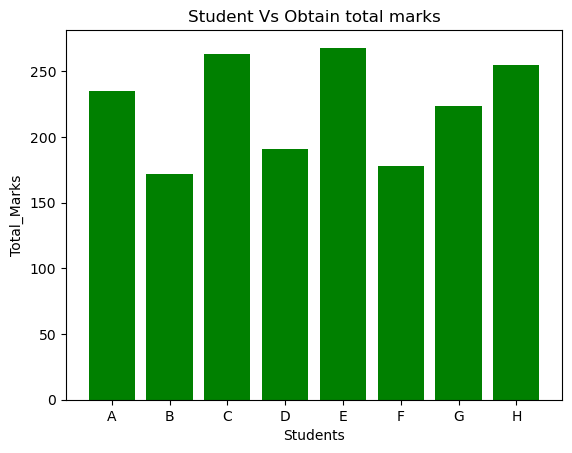

In [36]:
plt.bar(df["Student"],df["Total_Marks"],color="green")
plt.title("Student Vs Obtain total marks")
plt.xlabel("Students")
plt.ylabel("Total_Marks")

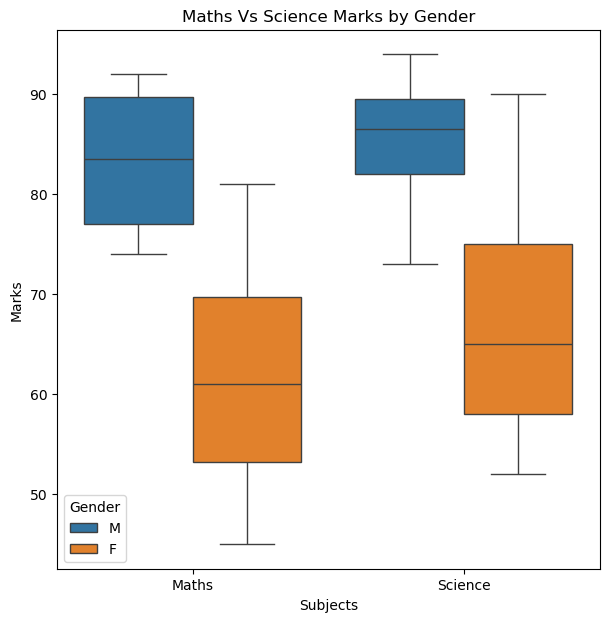

In [37]:
df_melt=df.melt(id_vars=["Student","Gender"],
                value_vars=["Maths","Science"],
                var_name="Subjects",
                value_name="Marks")

plt.figure(figsize=(7,7))
sns.boxplot(x="Subjects",y="Marks",hue="Gender",data=df_melt)
plt.title("Maths Vs Science Marks by Gender")
plt.show()

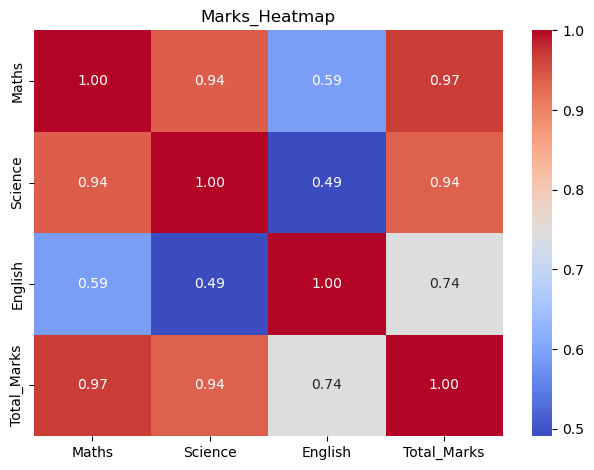

In [46]:
corr=df[["Maths","Science","English","Total_Marks"]].corr()
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f")

plt.title("Marks_Heatmap")
plt.tight_layout()